#### **Importing the Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

#### **Importing the file**

In [2]:
df_2009 = pd.read_excel(r"C:\Users\Dell\Documents\online_retail_II.xlsx\online_retail_II.xlsx", sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(r"C:\Users\Dell\Documents\online_retail_II.xlsx\online_retail_II.xlsx", sheet_name="Year 2010-2011")

# Combine both
df = pd.concat([df_2009, df_2010], ignore_index=True)

print(df.shape)

(1067371, 8)


#### **Data Cleaning**

In [4]:
df.duplicated().sum()

np.int64(34335)

In [5]:
df = df.drop_duplicates()

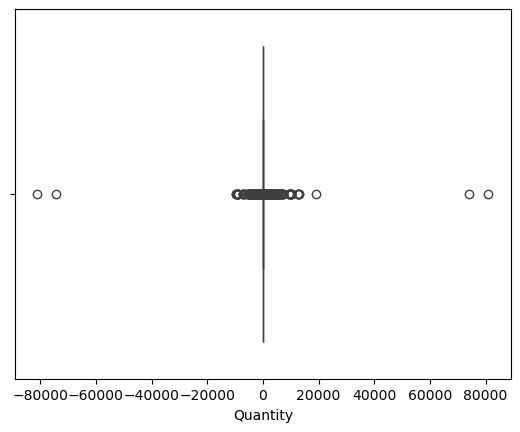

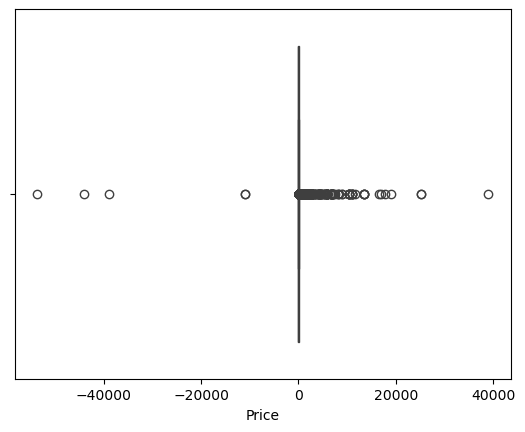

In [6]:
import seaborn as sns
sns.boxplot(x=df["Quantity"])
plt.show()

sns.boxplot(x=df["Price"])
plt.show()

In [7]:
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

In [8]:
df = df.dropna(subset=["Customer ID"])

In [9]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]

#### **Removing the anomaly**

In [10]:
df = df[~((df["Customer ID"] == 16446) & (df["Quantity"] > 50000))]

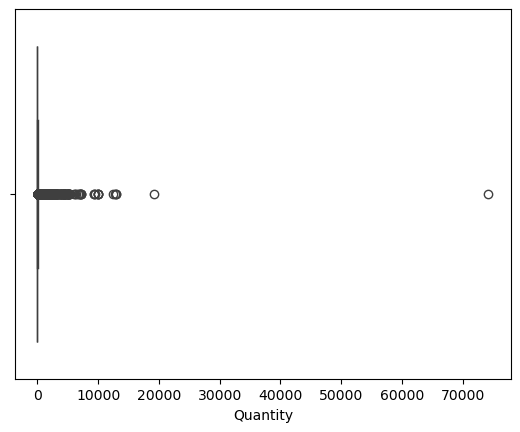

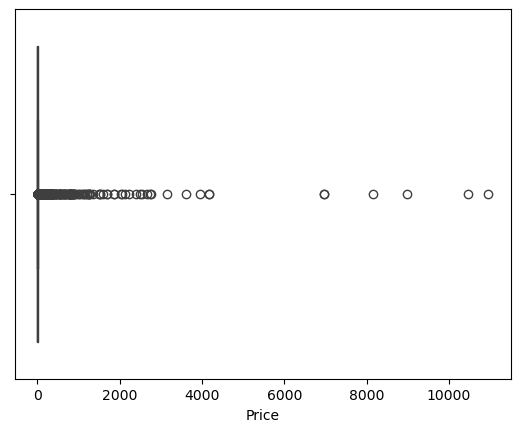

In [11]:
sns.boxplot(x=df["Quantity"])
plt.show()

sns.boxplot(x=df["Price"])
plt.show()

In [12]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Date'] = df['InvoiceDate'].dt.date

In [13]:
print("Dataset shape:", df.shape)

Dataset shape: (779424, 10)


#### **Revenue Time Series**

In [13]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Revenue']
monthly_revenue['Month'] = monthly_revenue['Month'].dt.to_timestamp()
monthly_revenue.set_index('Month', inplace=True)

print(monthly_revenue)
print(f"\nTotal months: {len(monthly_revenue)}")

                Revenue
Month                  
2009-12-01   683504.010
2010-01-01   555802.672
2010-02-01   504558.956
2010-03-01   696978.471
2010-04-01   591982.002
2010-05-01   597833.380
2010-06-01   636371.130
2010-07-01   589736.170
2010-08-01   602224.600
2010-09-01   829013.951
2010-10-01  1033112.010
2010-11-01  1166460.022
2010-12-01   570422.730
2011-01-01   568101.310
2011-02-01   446084.920
2011-03-01   594081.760
2011-04-01   468374.331
2011-05-01   677355.150
2011-06-01   660046.050
2011-07-01   598962.901
2011-08-01   644051.040
2011-09-01   950690.202
2011-10-01  1035642.450
2011-11-01  1156205.610
2011-12-01   348738.840

Total months: 25


#### **Monthly Revenue**

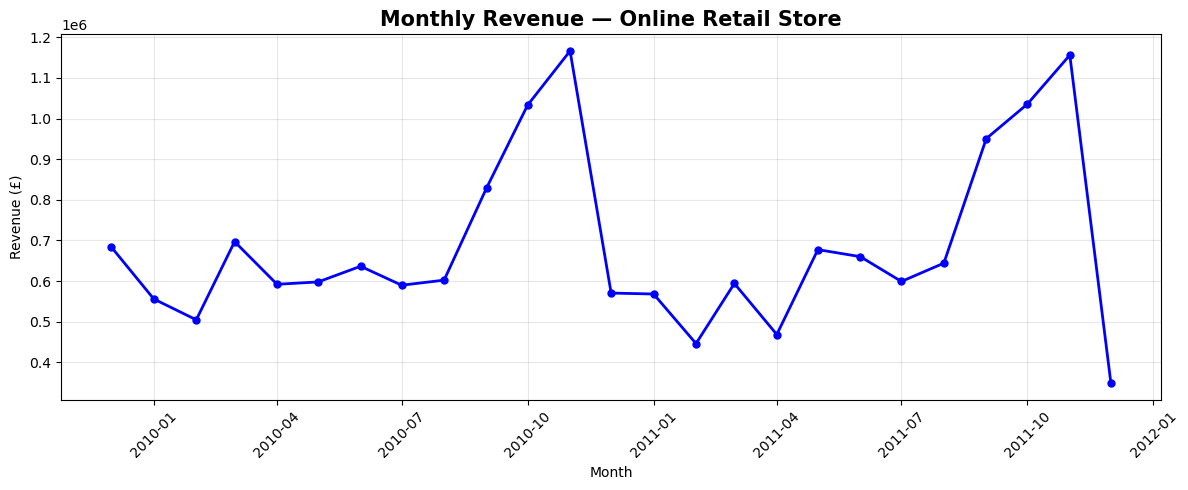

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue['Revenue'], 
         marker='o', color='blue', linewidth=2, markersize=5)
plt.title('Monthly Revenue — Online Retail Store', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### **ADF Stationarity Test**

In [15]:
def check_stationarity(series):
    result = adfuller(series.dropna())
    print('=== ADF Stationarity Test ===')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Critical Values: ')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print('\n✅ Data is STATIONARY (p ≤ 0.05) — Ready for ARIMA!')
    else:
        print('\n❌ Data is NOT STATIONARY (p > 0.05) — Needs differencing!')

check_stationarity(monthly_revenue['Revenue'])

=== ADF Stationarity Test ===
ADF Statistic : -3.1869
p-value       : 0.0208
Critical Values: 
   1%: -3.9644
   5%: -3.0849
   10%: -2.6818

✅ Data is STATIONARY (p ≤ 0.05) — Ready for ARIMA!


#### **Plotting ACF & PACF (To Find p and q)**

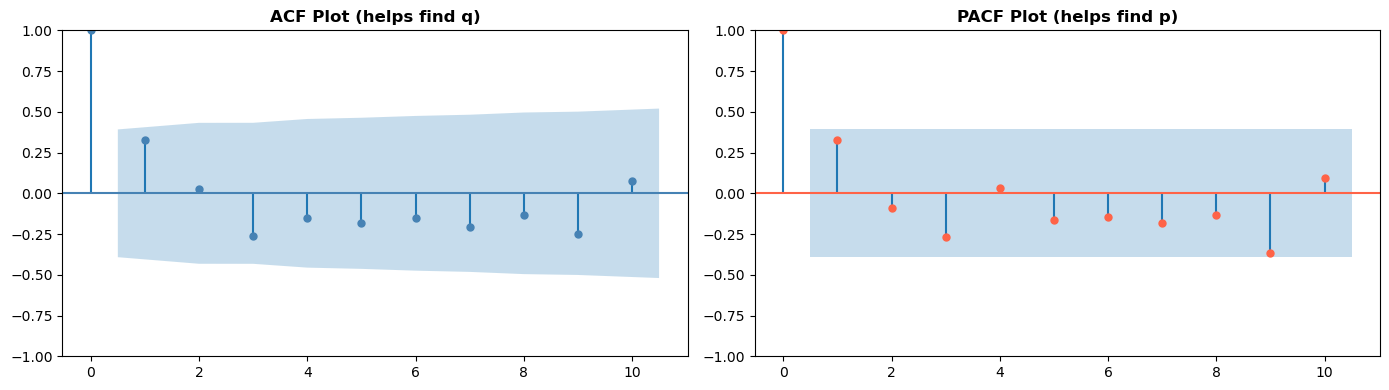

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF plot → helps find q (MA order)
plot_acf(monthly_revenue['Revenue'].dropna(), lags=10, ax=axes[0], color='steelblue')
axes[0].set_title('ACF Plot (helps find q)', fontweight='bold')

# PACF plot → helps find p (AR order)
plot_pacf(monthly_revenue['Revenue'].dropna(), lags=10, ax=axes[1], color='tomato')
axes[1].set_title('PACF Plot (helps find p)', fontweight='bold')

plt.tight_layout()
plt.show()

#### **Auto ARIMA(To find the best order)**

In [17]:
from pmdarima import auto_arima

auto_model = auto_arima(monthly_revenue['Revenue'],
                        start_p=0, start_q=0,
                        max_p=5, max_q=5,
                        d=None,              # auto-detect d
                        seasonal=False,
                        stepwise=True,
                        information_criterion='aic',
                        trace=True,          # prints all tested models
                        error_action='ignore',
                        suppress_warnings=True)

print(auto_model.summary())
print(f"\n✅ Best Order: {auto_model.order}")

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=747.330, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=695.846, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=732.503, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=697.661, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=697.653, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=696.452, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=687.349, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=688.414, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=688.189, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=689.105, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=687.415, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=689.898, Time=0.22 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.783 seconds
                               SARIMAX Results                                
Dep. Variable:       

#### **Residual Checking**

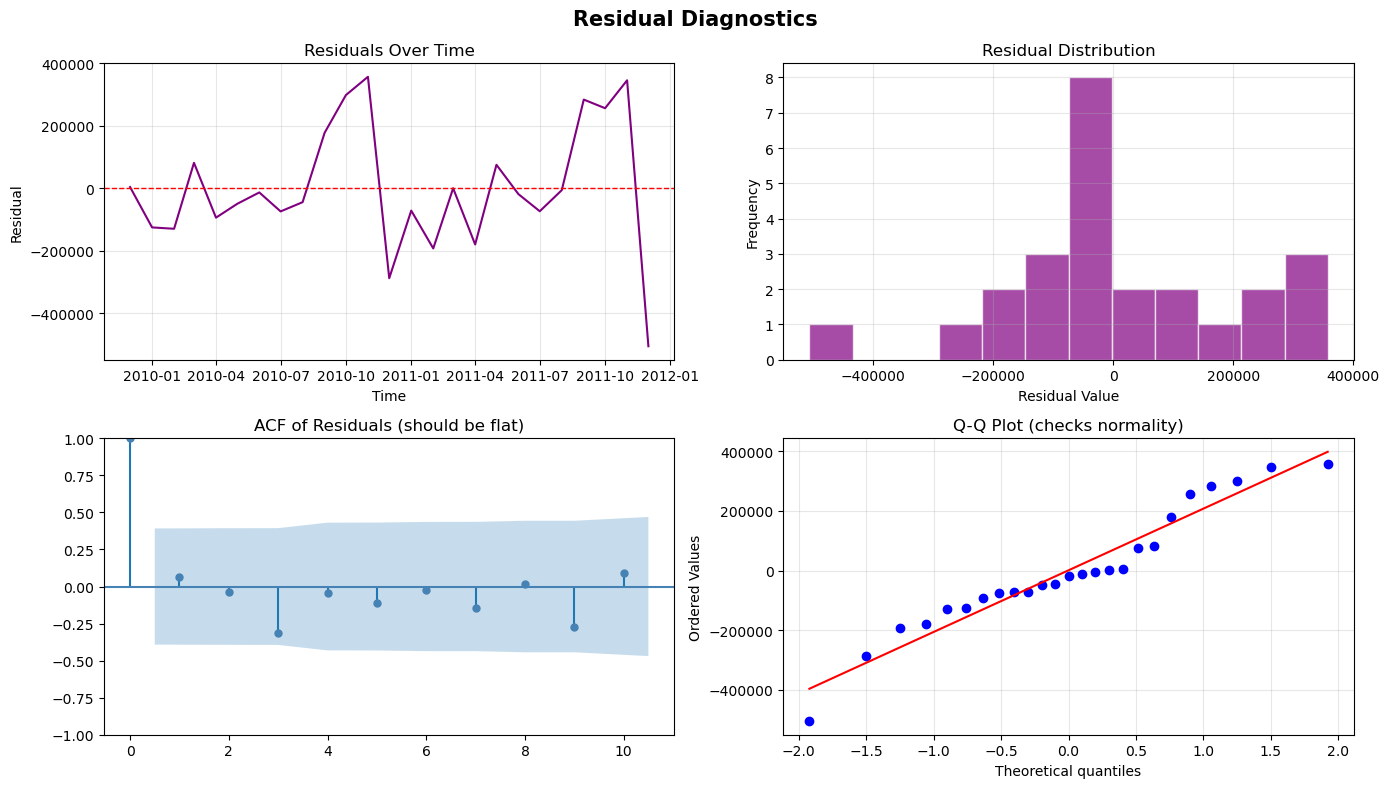

Mean of Residuals : 884.5532  (should be close to 0)
Std of Residuals  : 203849.2915


In [18]:
residuals = pd.Series(auto_model.resid())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Residual Diagnostics', fontsize=15, fontweight='bold')

# Plot 1 — Residuals over time
axes[0, 0].plot(residuals, color='purple', linewidth=1.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2 — Residual distribution
axes[0, 1].hist(residuals, bins=12, color='purple', edgecolor='white', alpha=0.7)
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3 — ACF of residuals (should show no pattern)
plot_acf(residuals, lags=10, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('ACF of Residuals (should be flat)')

# Plot 4 — Q-Q plot (checks normality)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (checks normality)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print(f"Mean of Residuals : {residuals.mean():.4f}  (should be close to 0)")
print(f"Std of Residuals  : {residuals.std():.4f}")

#### **Forecasting Revenue for the next 3 months**

In [19]:
# Forecast next 3 months
forecast_steps = 3
forecast_values, conf_int = auto_model.predict(n_periods=forecast_steps, 
                                                return_conf_int=True)

forecast_index = pd.date_range(
    start=monthly_revenue.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Forecasted Revenue': forecast_values,
    'Lower Bound': conf_int[:, 0],
    'Upper Bound': conf_int[:, 1]
}, index=forecast_index)

print("📅 Revenue Forecast:")
print(forecast_df.to_string())

📅 Revenue Forecast:
            Forecasted Revenue    Lower Bound   Upper Bound
2012-01-01       557875.700631  158341.113852  9.574103e+05
2012-02-01       634652.818870  209045.731509  1.060260e+06
2012-03-01       662838.791765  233838.990302  1.091839e+06


#### **Monthly Revenue Forecast(ARIMA)** 

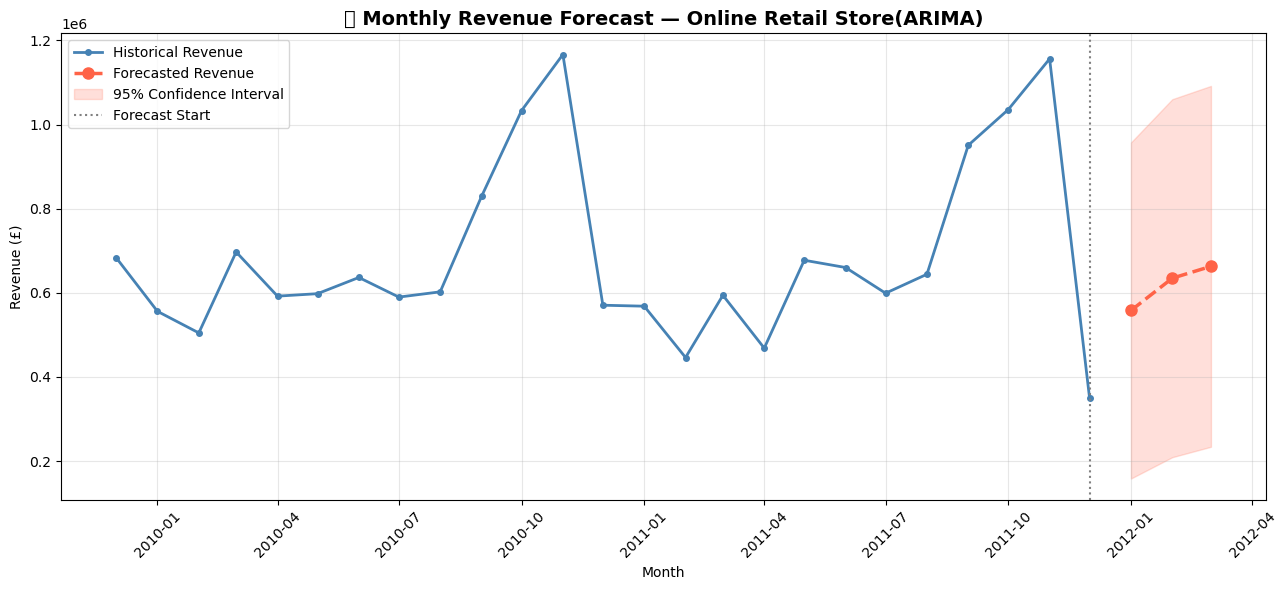

In [30]:
plt.figure(figsize=(13, 6))

# Historical data
plt.plot(monthly_revenue.index, monthly_revenue['Revenue'],
         label='Historical Revenue', color='steelblue', 
         linewidth=2, marker='o', markersize=4)

# Forecasted values
plt.plot(forecast_df.index, forecast_df['Forecasted Revenue'],
         label='Forecasted Revenue', color='tomato', 
         linewidth=2.5, marker='o', markersize=8, linestyle='--')

# Confidence interval shading
plt.fill_between(forecast_df.index,
                 forecast_df['Lower Bound'],
                 forecast_df['Upper Bound'],
                 color='tomato', alpha=0.2, 
                 label='95% Confidence Interval')

# Vertical divider line
plt.axvline(x=monthly_revenue.index[-1], 
            color='gray', linestyle=':', linewidth=1.5,
            label='Forecast Start')

plt.title('📅 Monthly Revenue Forecast — Online Retail Store(ARIMA)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Model Evaluation (MAE, RMSE, MAPE) - ARIMA**

       📏 Model Evaluation Results
MAE   (Mean Absolute Error)       : £342,343.60
RMSE  (Root Mean Squared Error)   : £351,017.58
MAPE  (Mean Abs Percentage Error) : 53.10%


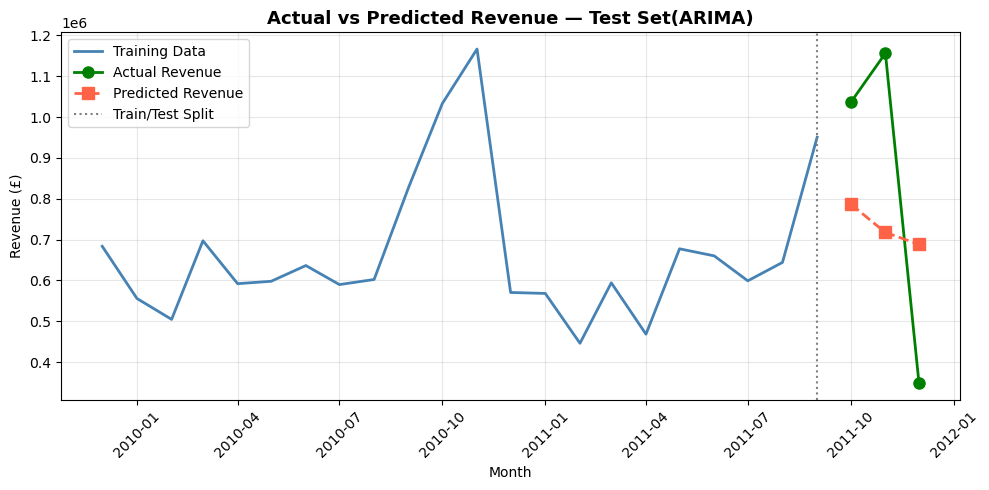

In [31]:
# Split into train and test (last 3 months as test)
train = monthly_revenue['Revenue'][:-3]
test  = monthly_revenue['Revenue'][-3:]

# Fit model on training data using same order
from statsmodels.tsa.arima.model import ARIMA

eval_model = ARIMA(train, order=(1, 0, 0))
eval_fit = eval_model.fit()

# Predict the test period
predictions = eval_fit.forecast(steps=3)
predictions.index = test.index

# Calculate metrics
mae  = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test.values - predictions.values) / test.values)) * 100

print("=" * 40)
print("       📏 Model Evaluation Results")
print("=" * 40)
print(f"MAE   (Mean Absolute Error)       : £{mae:,.2f}")
print(f"RMSE  (Root Mean Squared Error)   : £{rmse:,.2f}")
print(f"MAPE  (Mean Abs Percentage Error) : {mape:.2f}%")
print("=" * 40)

# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', 
         color='steelblue', linewidth=2)
plt.plot(test.index, test.values, label='Actual Revenue', 
         color='green', linewidth=2, marker='o', markersize=8)
plt.plot(predictions.index, predictions.values, label='Predicted Revenue', 
         color='tomato', linewidth=2, marker='s', 
         markersize=8, linestyle='--')

plt.axvline(x=train.index[-1], color='gray', 
            linestyle=':', linewidth=1.5, label='Train/Test Split')

plt.title('Actual vs Predicted Revenue — Test Set(ARIMA)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Removing the incomplete December 2011 month**

In [22]:
monthly_revenue_clean = monthly_revenue[monthly_revenue.index != '2011-12-01']

print(f"Original data points : {len(monthly_revenue)}")
print(f"After removing Dec   : {len(monthly_revenue_clean)}")
print(f"\nLast 3 months now:")
print(monthly_revenue_clean.tail(3))

Original data points : 25
After removing Dec   : 24

Last 3 months now:
                Revenue
Month                  
2011-09-01   950690.202
2011-10-01  1035642.450
2011-11-01  1156205.610


Test set months:
Month
2011-09-01     950690.202
2011-10-01    1035642.450
2011-11-01    1156205.610
Name: Revenue, dtype: float64

     📏 Model Evaluation (Without Dec 2011) ARIMA
MAE   (Mean Absolute Error)       : £396,527.01
RMSE  (Root Mean Squared Error)   : £405,132.58
MAPE  (Mean Abs Percentage Error) : 37.46%


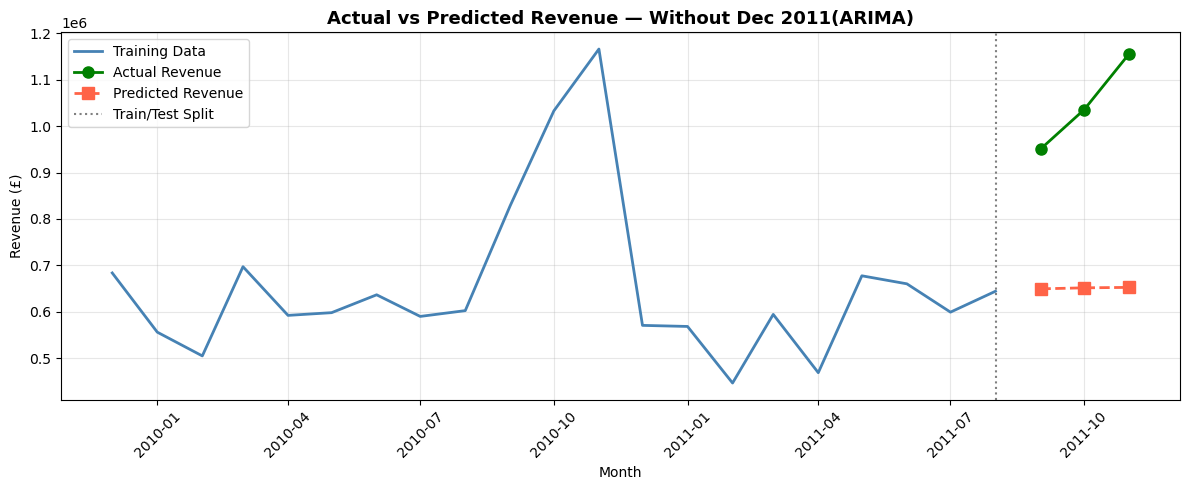

In [32]:
# New train/test split without December
train_clean = monthly_revenue_clean['Revenue'][:-3]
test_clean  = monthly_revenue_clean['Revenue'][-3:]

print("Test set months:")
print(test_clean)

# Refit model on clean training data
eval_model_clean = ARIMA(train_clean, order=(1, 0, 0))
eval_fit_clean = eval_model_clean.fit()

# Predict
predictions_clean = eval_fit_clean.forecast(steps=3)
predictions_clean.index = test_clean.index

# Recalculate metrics
mae_clean  = mean_absolute_error(test_clean, predictions_clean)
rmse_clean = np.sqrt(mean_squared_error(test_clean, predictions_clean))
mape_clean = np.mean(np.abs((test_clean.values - predictions_clean.values) / test_clean.values)) * 100

print("\n" + "=" * 45)
print("     📏 Model Evaluation (Without Dec 2011) ARIMA")
print("=" * 45)
print(f"MAE   (Mean Absolute Error)       : £{mae_clean:,.2f}")
print(f"RMSE  (Root Mean Squared Error)   : £{rmse_clean:,.2f}")
print(f"MAPE  (Mean Abs Percentage Error) : {mape_clean:.2f}%")
print("=" * 45)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(train_clean.index, train_clean, 
         label='Training Data', color='steelblue', linewidth=2)
plt.plot(test_clean.index, test_clean.values, 
         label='Actual Revenue', color='green', 
         linewidth=2, marker='o', markersize=8)
plt.plot(predictions_clean.index, predictions_clean.values, 
         label='Predicted Revenue', color='tomato', 
         linewidth=2, marker='s', markersize=8, linestyle='--')

plt.axvline(x=train_clean.index[-1], color='gray', 
            linestyle=':', linewidth=1.5, label='Train/Test Split')

plt.title('Actual vs Predicted Revenue — Without Dec 2011(ARIMA)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Trying SARIMA Since it would handle the seasonal spikes properly**

In [24]:
from pmdarima import auto_arima

sarima_model = auto_arima(monthly_revenue_clean['Revenue'],
                          start_p=0, start_q=0,
                          max_p=2, max_q=2,
                          d=0,
                          seasonal=True,       # ← Key change!
                          m=12,                # ← 12 months = yearly seasonality
                          start_P=0, start_Q=0,
                          max_P=1, max_Q=1,
                          D=0,
                          stepwise=True,
                          information_criterion='aic',
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True)

print("\n✅ Best SARIMA Order:", sarima_model.order)
print("✅ Best Seasonal Order:", sarima_model.seasonal_order)
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=659.333, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=648.408, Time=0.17 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=652.585, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=718.271, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=651.566, Time=0.03 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=649.791, Time=0.12 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=649.368, Time=0.07 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=660.917, Time=0.05 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=650.299, Time=0.22 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=650.687, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=656.447, Time=0.20 sec
 ARIMA(2,0,1)(1,0,0)[12] intercept   : AIC=651.649, Time=0.38 sec
 ARIMA(1,0,0)(1,0,0)[12]             : AIC=653.011, Time=0.11 sec

Best model:  ARIMA(1,0,0)(1,0,0)[12] intercept
Total fit time: 1.878 seconds

✅ Best SARIMA Order:

#### **SARIMA Model Evaluation**

In [25]:
# Train/test split on clean data
train_clean = monthly_revenue_clean['Revenue'][:-3]
test_clean  = monthly_revenue_clean['Revenue'][-3:]

# Refit SARIMA on training data
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_eval = SARIMAX(train_clean, 
                      order=(1, 0, 0),
                      seasonal_order=(1, 0, 0, 12))
sarima_eval_fit = sarima_eval.fit(disp=False)

# Predict test period
predictions_sarima = sarima_eval_fit.forecast(steps=3)
predictions_sarima.index = test_clean.index

# Metrics
mae_s  = mean_absolute_error(test_clean, predictions_sarima)
rmse_s = np.sqrt(mean_squared_error(test_clean, predictions_sarima))
mape_s = np.mean(np.abs((test_clean.values - predictions_sarima.values) / test_clean.values)) * 100

print("=" * 50)
print("   📏 SARIMA Model Evaluation (Without Dec 2011)")
print("=" * 50)
print(f"MAE   : £{mae_s:,.2f}")
print(f"RMSE  : £{rmse_s:,.2f}")
print(f"MAPE  : {mape_s:.2f}%")
print("=" * 50)

# Compare both models
print("\n📊 ARIMA vs SARIMA Comparison:")
print(f"{'Metric':<8} {'ARIMA':>12} {'SARIMA':>12} {'Improvement':>12}")
print("-" * 46)
print(f"{'MAPE':<8} {'37.46%':>12} {f'{mape_s:.2f}%':>12} {f'{37.46 - mape_s:.2f}%':>12}")
print(f"{'MAE':<8} {'£396,527':>12} {f'£{mae_s:,.0f}':>12}")
print(f"{'RMSE':<8} {'£405,132':>12} {f'£{rmse_s:,.0f}':>12}")


   📏 SARIMA Model Evaluation (Without Dec 2011)
MAE   : £202,579.31
RMSE  : £204,156.95
MAPE  : 19.32%

📊 ARIMA vs SARIMA Comparison:
Metric          ARIMA       SARIMA  Improvement
----------------------------------------------
MAPE           37.46%       19.32%       18.14%
MAE          £396,527     £202,579
RMSE         £405,132     £204,157


#### **SARIMA — Actual vs Predicted Revenue**

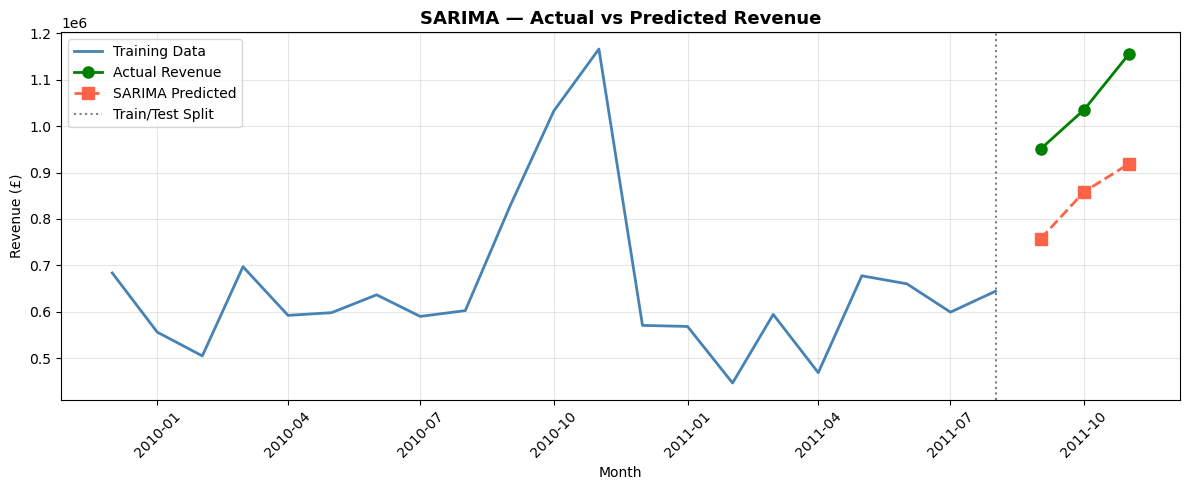

In [26]:
# Plot
plt.figure(figsize=(12, 5))
plt.plot(train_clean.index, train_clean,
         label='Training Data', color='steelblue', linewidth=2)
plt.plot(test_clean.index, test_clean.values,
         label='Actual Revenue', color='green',
         linewidth=2, marker='o', markersize=8)
plt.plot(predictions_sarima.index, predictions_sarima.values,
         label='SARIMA Predicted', color='tomato',
         linewidth=2, marker='s', markersize=8, linestyle='--')

plt.axvline(x=train_clean.index[-1], color='gray',
            linestyle=':', linewidth=1.5, label='Train/Test Split')
plt.title('SARIMA — Actual vs Predicted Revenue', 
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Fitting final SARIMA on complete clean data (all 24 months)
final_sarima = SARIMAX(monthly_revenue_clean['Revenue'],
                       order=(1, 0, 0),
                       seasonal_order=(1, 0, 0, 12))
final_sarima_fit = final_sarima.fit(disp=False)

# Forecasting next 3 months (Jan, Feb, Mar 2012)
forecast_steps = 3
forecast_obj = final_sarima_fit.get_forecast(steps=forecast_steps)
forecast_values = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

In [28]:
# Creating forecast index
forecast_index = pd.date_range(
    start=monthly_revenue_clean.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq='MS'
)
forecast_values.index = forecast_index
conf_int.index = forecast_index

        📅 SARIMA Revenue Forecast — Dec to Feb 2012
December 2011  →  £736,554   (Range: £381,496 – £1,091,611)
January 2012  →  £703,259   (Range: £222,321 – £1,184,196)
February 2012  →  £595,424   (Range: £30,492 – £1,160,356)


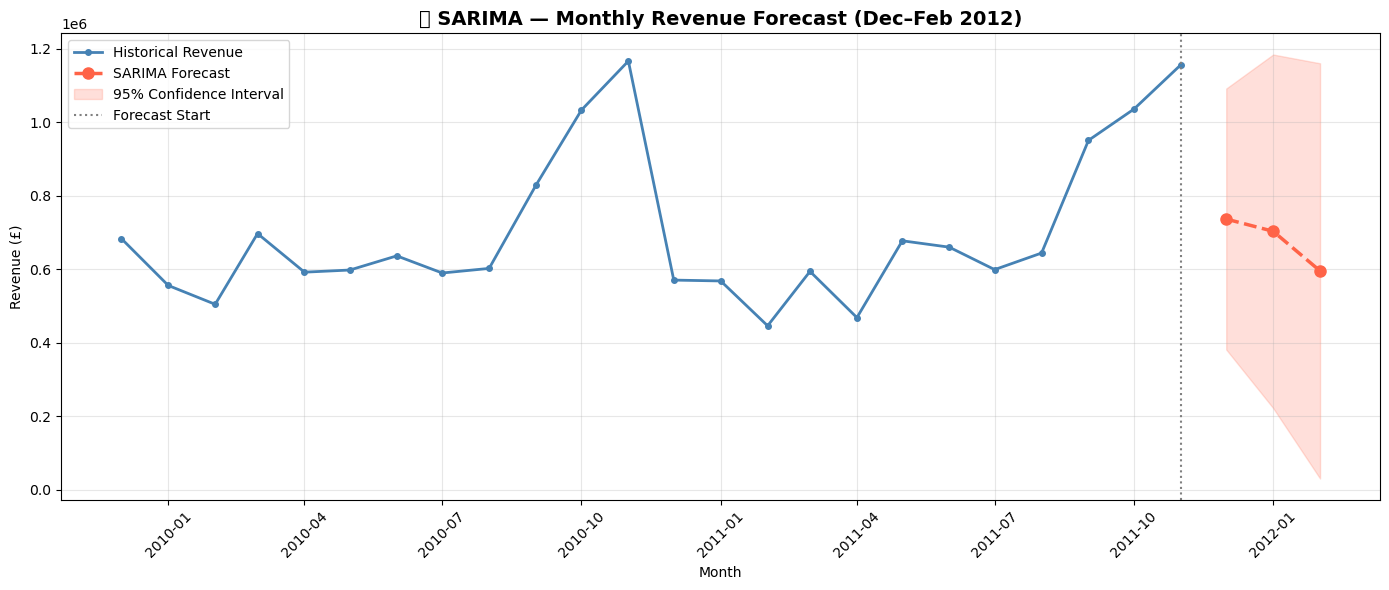

In [33]:
# Print forecast table
print("=" * 60)
print("        📅 SARIMA Revenue Forecast — Dec to Feb 2012")
print("=" * 60)
for date, val, low, high in zip(forecast_index,
                                 forecast_values,
                                 conf_int.iloc[:, 0],
                                 conf_int.iloc[:, 1]):
    print(f"{date.strftime('%B %Y')}  →  £{val:,.0f}   "
          f"(Range: £{low:,.0f} – £{high:,.0f})")
print("=" * 60)

# Plot
plt.figure(figsize=(14, 6))

# Historical
plt.plot(monthly_revenue_clean.index,
         monthly_revenue_clean['Revenue'],
         label='Historical Revenue', color='steelblue',
         linewidth=2, marker='o', markersize=4)

# Forecast
plt.plot(forecast_values.index, forecast_values,
         label='SARIMA Forecast', color='tomato',
         linewidth=2.5, marker='o', markersize=8, linestyle='--')

# Confidence interval
plt.fill_between(forecast_values.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='tomato', alpha=0.2,
                 label='95% Confidence Interval')

# Divider
plt.axvline(x=monthly_revenue_clean.index[-1],
            color='gray', linestyle=':', linewidth=1.5,
            label='Forecast Start')

plt.title('📈 SARIMA — Monthly Revenue Forecast (Dec–Feb 2012)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Conclusion** — Revenue Forecasting Project
This project successfully built an end-to-end revenue forecasting pipeline for an online retail store using the Online Retail II dataset. After cleaning and aggregating over 1 million transactions into a monthly time series, the ADF test confirmed stationarity and ACF/PACF plots guided model selection. The baseline **ARIMA(1,0,0)** model achieved a **MAPE** of **37.46%** but struggled to capture the **strong yearly holiday season spikes**. Upgrading to **SARIMA(1,0,0)(1,0,0)[12]** — which explicitly models the **12-month seasonal cycle** — reduced the **MAPE** to **19.32%**, cutting errors by **nearly 50%**. The final model **correctly predicted a post-holiday revenue cooldown** for early 2012, demonstrating that for retail data, handling seasonality is the single most impactful improvement a forecasting model can make.